In [1]:
import os
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)

### Funções auxiliares

In [2]:
def plot_variable_distribution(df, var, bins=range(0, 101, 10)):
    """
    Gera visualizações da distribuição de uma variável em um DataFrame.

    Parâmetros:
    -----------
    df : pandas.DataFrame
        Conjunto de dados contendo a variável a ser analisada.
        
    var : str
        Nome da variável cuja distribuição será plotada.
        
    bins : list or range, opcional (default=range(0, 101, 10))
        Intervalos utilizados para agrupar variáveis numéricas. Ignorado para variáveis categóricas.

    """


    if var == 'month':
        month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 
                       'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
        
        month_counts = df[var].value_counts().reindex(month_order)

        plt.figure(figsize=(10, 5))
        ax = sns.lineplot(x=month_counts.index, y=month_counts.values, marker='o')

        for x, y in zip(month_counts.index, month_counts.values):
            ax.text(x, y + 50, f'{y:,.0f}'.replace(',', '.'), ha='center', va='bottom')

        ax.set_xlabel('Mês')
        ax.set_ylabel('Volumetria da amostra')
        ax.set_title('Distribuição da amostra por mês de contato')
        ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)
        plt.tight_layout()
        plt.show()
        return

    if pd.api.types.is_numeric_dtype(df[var]):
        labels = [f"{i}-{i+9}" for i in bins[:-1]]
        group_var = f'{var}_group'
        df[group_var] = pd.cut(df[var], bins=bins, labels=labels, right=False)
        group_counts = df[group_var].value_counts().sort_index()

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 5), gridspec_kw={'width_ratios': [3, 1]})
        sns.barplot(x=group_counts.index, y=group_counts.values, color='lightblue', ax=ax1)

        for container in ax1.containers:
            labels = [f"{val.get_height():,.0f}".replace(',', '.') for val in container]
            ax1.bar_label(container, labels=labels)

        ax1.set_xlabel('Faixa')
        ax1.set_ylabel('Volumetria da amostra')
        ax1.set_title(f'Volumetria da amostra por faixa de {var}')
        ax1.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

        sns.boxplot(y=df[var], color='lightblue', ax=ax2)
        ax2.set_title(f'Distribuição de {var.capitalize()}')
        ax2.set_ylabel(var.capitalize())
        ax2.set_xlabel('')
        ax2.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

        plt.tight_layout()
        plt.show()

    else:
        # Categórica genérica
        value_counts = df[var].value_counts().sort_index()
        plt.figure(figsize=(max(8, len(value_counts) * 0.6), 5))
        ax = sns.barplot(x=value_counts.index, y=value_counts.values, color='lightblue')

        for patch in ax.patches:
            height = patch.get_height()
            ax.text(
                patch.get_x() + patch.get_width() / 2,
                height + 5,
                f'{height:,.0f}'.replace(',', '.'),
                ha='center',
                va='bottom'
            )

        ax.set_xlabel(var.capitalize())
        ax.set_ylabel('Volumetria da amostra')
        ax.set_title(f'Distribuição da amostra por {var}')
        ax.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

        if len(value_counts) > 5:
            plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.show()


def plot_boxplot(df, cat_var, num_var, figsize=(10, 6), palette='pastel'):
    """
    Plota um boxplot para uma variável numérica e uma variável categórica.

    Parâmetros:
    - df: DataFrame
    - cat_var: nome da variável categórica (string)
    - num_var: nome da variável numérica (string)
    - figsize: tamanho da figura (default: (10, 6))
    - palette: paleta de cores do seaborn (default: 'pastel')
    """
    plt.figure(figsize=figsize)
    sns.boxplot(x=cat_var, y=num_var, data=df, palette=palette)

    plt.xlabel(cat_var.capitalize())
    plt.ylabel(num_var.capitalize())
    plt.title(f'Distribuição de {num_var} por {cat_var}')
    plt.grid(True, linestyle='--', linewidth=0.5, color='gray', alpha=0.5)

    plt.tight_layout()
    plt.show()

# Leitura da base raw

In [3]:
df_raw = pd.read_csv(os.path.join('..', 'data', 'raw', 'MeliDataset.csv'), sep=";")

print(df_raw.shape)
df_raw.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [4]:
df_raw = df_raw.drop_duplicates()
df_raw.shape

(41176, 21)

In [5]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 41176 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41176 non-null  int64  
 1   job             41176 non-null  object 
 2   marital         41176 non-null  object 
 3   education       41176 non-null  object 
 4   default         41176 non-null  object 
 5   housing         41176 non-null  object 
 6   loan            41176 non-null  object 
 7   contact         41176 non-null  object 
 8   month           41176 non-null  object 
 9   day_of_week     41176 non-null  object 
 10  duration        41176 non-null  int64  
 11  campaign        41176 non-null  int64  
 12  pdays           41176 non-null  int64  
 13  previous        41176 non-null  int64  
 14  poutcome        41176 non-null  object 
 15  emp.var.rate    41176 non-null  float64
 16  cons.price.idx  41176 non-null  float64
 17  cons.conf.idx   41176 non-null 

In [6]:
(df_raw.shape[0] - df_raw.isnull().sum()) / (df_raw.shape[0])

age               1.0
job               1.0
marital           1.0
education         1.0
default           1.0
housing           1.0
loan              1.0
contact           1.0
month             1.0
day_of_week       1.0
duration          1.0
campaign          1.0
pdays             1.0
previous          1.0
poutcome          1.0
emp.var.rate      1.0
cons.price.idx    1.0
cons.conf.idx     1.0
euribor3m         1.0
nr.employed       1.0
y                 1.0
dtype: float64

In [7]:
df_raw.columns[df_raw.isnull().all()]

Index([], dtype='object')

### Informações dos clientes Meli

Neste bloco são analisadas as variáveis que descrevem o perfil sociodemográfico e a situação financeira dos clientes, tais como idade, tipo de ocupação, estado civil, nível educacional, bem como a presença de inadimplência, financiamento habitacional e empréstimo pessoal.

O perfil dos clientes contactados apresenta uma idade média de 40 anos. Em relação à ocupação, observa-se uma predominância das profissões administrador, trabalhador braçal (blue-collar) e técnico (technician), que, juntas, representam aproximadamente 64% da amostra. Dado o grande número de categorias ocupacionais distintas, pode ser interessante reagrupar as profissões em categorias mais amplas, como empregados, não empregados e desconhecido, a fim de facilitar a análise e reduzir a sparsidade da variável. Além disso, a taxa de resposta positiva à campanha (y = 1) varia entre as ocupações — por exemplo, estudantes (31,4%) e aposentados (25,2%) apresentaram proporções superiores à média geral, indicando o grupo de "não empregados" como possível segmento com maior propensão de engajamento.

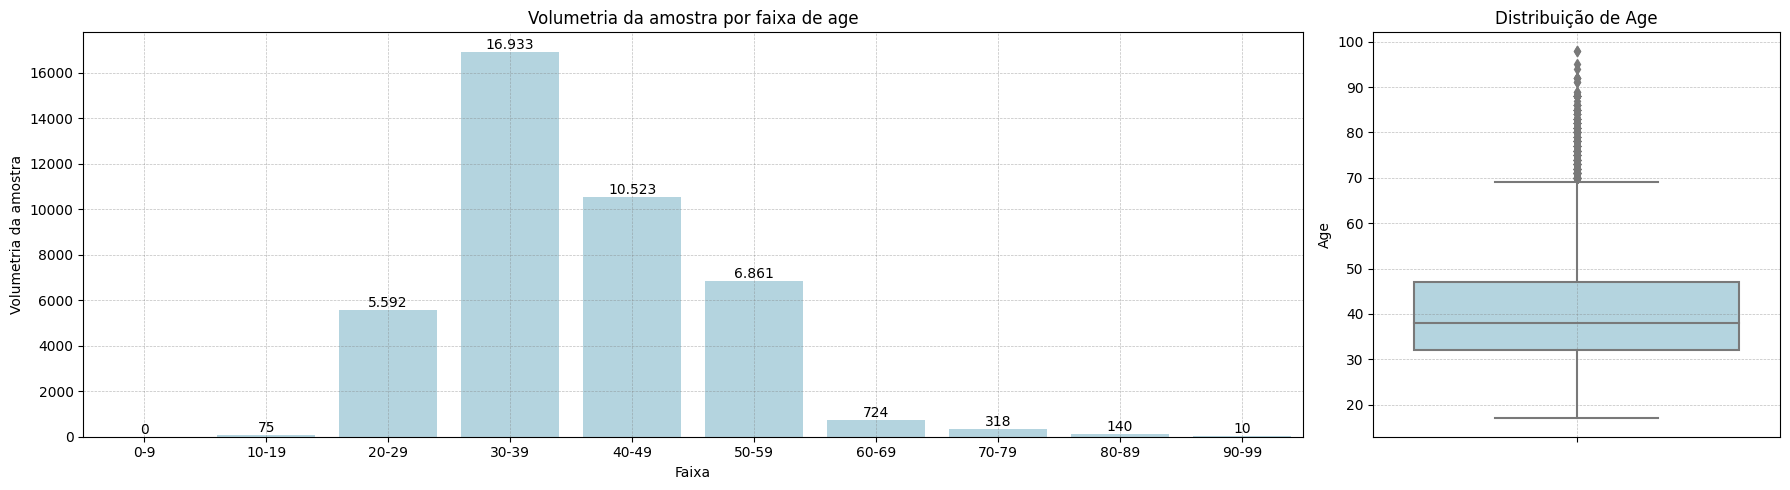

In [8]:
plot_variable_distribution(df_raw, 'age')

In [9]:
df_raw['age'].describe()

count    41176.00000
mean        40.02380
std         10.42068
min         17.00000
25%         32.00000
50%         38.00000
75%         47.00000
max         98.00000
Name: age, dtype: float64

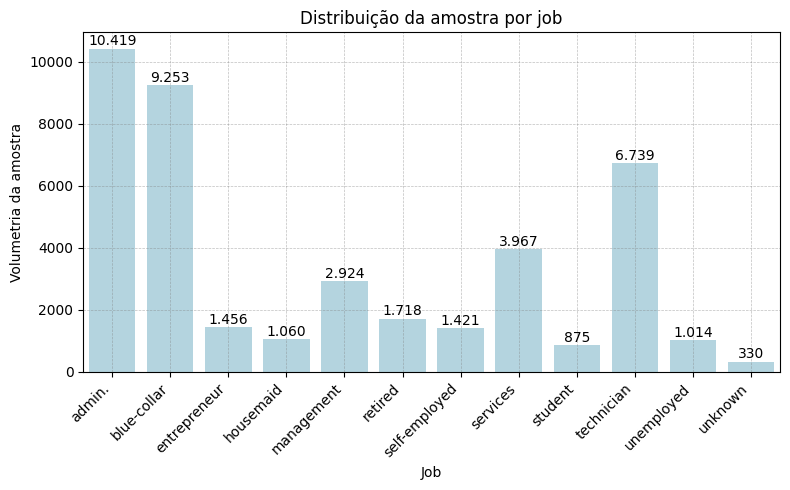

In [10]:
plot_variable_distribution(df_raw, 'job')  

In [11]:
df_raw.groupby('job')['y'].value_counts(normalize=True).unstack()

y,no,yes
job,,
admin.,0.870333,0.129667
blue-collar,0.931049,0.068951
entrepreneur,0.914835,0.085165
housemaid,0.900000,0.100000
management,0.887825,0.112175
retired,0.747381,0.252619
self-employed,0.895144,0.104856
services,0.918578,0.081422
student,0.685714,0.314286


Quanto ao estado civil, a maioria dos clientes são casados, com menor proporção de indivíduos divorciados ou com estado civil desconhecido. Observa-se que clientes solteiros apresentam uma maior taxa de resposta positiva à campanha (y = 1, 14,0%), seguidos por aqueles com estado civil desconhecido (15,0%).

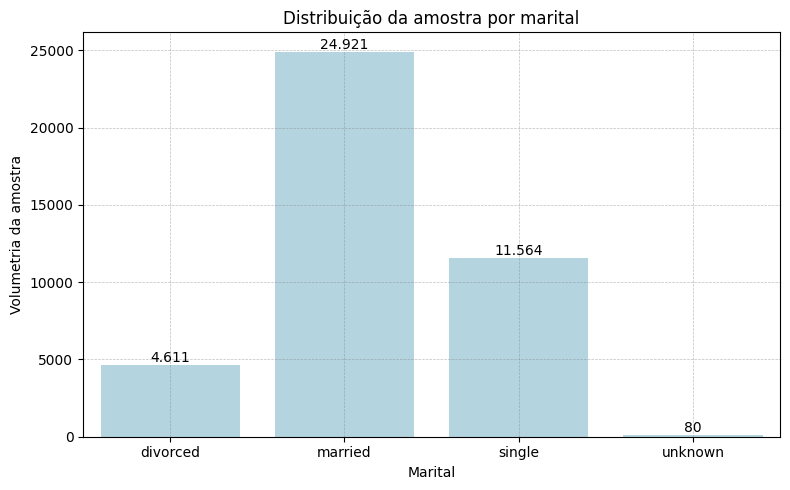

In [12]:
plot_variable_distribution(df_raw, 'marital')  

In [13]:
df_raw.groupby('marital')['y'].value_counts(normalize=True).unstack()

y,no,yes
marital,,
divorced,0.896769,0.103231
married,0.898439,0.101561
single,0.859910,0.140090
unknown,0.850000,0.150000


Para escolaridade, o grupo analfabeto (illiterate), que, embora represente uma fração muito pequena da base, possui uma taxa de conversão alta quanto comparada aos demais grupos (22,2%). Contudo, dado o pequeno número de observações nessa categoria, esse resultado deve ser interpretado com cautela. 

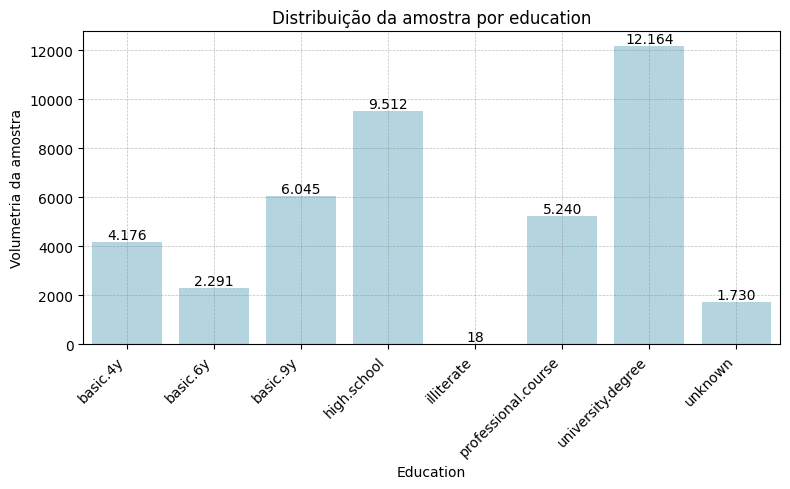

In [14]:
plot_variable_distribution(df_raw, 'education')  

In [15]:
df_raw.groupby('education')['y'].value_counts(normalize=True).unstack()

y,no,yes
education,,
basic.4y,0.897510,0.102490
basic.6y,0.917940,0.082060
basic.9y,0.921754,0.078246
high.school,0.891611,0.108389
illiterate,0.777778,0.222222
professional.course,0.886450,0.113550
university.degree,0.862792,0.137208
unknown,0.854913,0.145087


A variável de inadimplência (*default*) pode comprometer o poder de generalização do modelo, uma vez que todos os clientes identificados como inadimplentes (default = yes) não foram convertidos pela campanha (y = no). Embora esse grupo contenha apenas três observações, o padrão observado pode induzir o modelo a aprender uma associação espúria. 

In [ ]:
plot_variable_distribution(df_raw, 'default')  

In [ ]:
df_raw[df_raw['default']=='yes']

In [ ]:
df_raw[df_raw['euribor3m'] > 5]

In [ ]:
df_raw.groupby('default')['y'].value_counts(normalize=True).unstack()

In [ ]:
plot_variable_distribution(df_raw, 'housing')

In [ ]:
df_raw.groupby('housing')['y'].value_counts(normalize=True).unstack()

In [ ]:
plot_variable_distribution(df_raw, 'loan')

In [ ]:
df_raw.groupby('loan')['y'].value_counts(normalize=True).unstack()

### Dados da última campanha de contato MELI

Neste bloco será avaliado informações sobre a campanha de marketing realizada pelo MELI. 

Os resultados positivos da campanha são superiores para celular (14,7%), o que pode sugerir canal mais efetivo dado a flexibilidade em horários que o aparelho proporciona.

A variável mês (month), que representa o mês do último contato com os clientes, apresenta variações importantes nas taxas de conversão (y = yes). Os meses com maior proporção de respostas positivas foram março (50,5%), dezembro (48,9%), outubro (43,9%) e setembro (44,9%). Esses meses parecem ter se destacado em termos de eficácia da campanha. Por outro lado, os meses de maio (6,4%), julho (9,0%), junho (10,5%) e agosto (10,6%) apresentaram taxas de conversão consideravelmente mais baixas. Esses resultados sugerem possivelmente fatores sazonais, contextos econômicos temporários ou até estratégias comerciais mais eficazes em determinados períodos.

In [ ]:
plot_variable_distribution(df_raw, 'contact')  

In [ ]:
df_raw.groupby('contact')['y'].value_counts(normalize=True).unstack()

In [ ]:
plot_variable_distribution(df_raw, 'month')  

In [ ]:
month_order = ['mar', 'apr', 'may', 'jun', 
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df_raw.groupby('month')['y'].value_counts(normalize=True).unstack().reindex(month_order)

In [ ]:
plot_variable_distribution(df_raw, 'day_of_week')

In [ ]:
df_raw.groupby('day_of_week')['y'].value_counts(normalize=True).unstack()

In [ ]:
plot_variable_distribution(df_raw, 'duration')  

### Outros atributos

Ainda sobre informações sobre as campanhas de marketig, a variável campaign, que indica o número de vezes que um cliente foi contatado durante a campanha atual, sugere que aumentar excessivamente o número de contatos não está associado a maior taxa de sucesso, na verdade, a tendência oposta é observada. 

In [ ]:
plot_variable_distribution(df_raw, 'campaign', bins=range(0, 61, 5))  

Clientes não contatados anteriormente (pdays = 999) responderam positivamente em apenas 9,3% dos casos.

In [ ]:
def agrupar_pdays(valor):
    if valor == 999:
        return '999 (não contatado)'
    elif valor <= 4:
        return '0-4'
    elif valor <= 9:
        return '5-9'
    elif valor <= 14:
        return '10-14'
    elif valor <= 19:
        return '15-19'
    elif valor <= 24:
        return '20-24'
    elif valor <= 29:
        return '25-29'
    else:
        return '30+'

df_raw['pdays_group'] = df_raw['pdays'].apply(agrupar_pdays)

categoria_ordenada = ['0-4', '5-9', '10-14', '15-19', '20-24', '25-29', '30+', '999 (não contatado)']
df_raw['pdays_group'] = pd.Categorical(df_raw['pdays_group'], categories=categoria_ordenada, ordered=True)

df_raw.groupby('pdays_group')['y'].value_counts(normalize=True).unstack()


A análise mostra que entre os clientes sem histórico de contato prévio, apenas 8,8% responderam positivamente à campanha. Por outro lado, entre aqueles que já haviam sido contatados, a taxa de conversão foi significativamente maior, atingindo 26,6%.

In [ ]:
df_raw['previous_contact'] = df_raw['previous'].apply(lambda x: 'no' if x == 0 else 'yes')

plt.figure(figsize=(7, 4))
ax = sns.countplot(data=df_raw, x='previous_contact', 
                   palette='Blues', 
                   order=['no', 
                          'yes'])

for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f'n = {int(height):,}'.replace(',', '.'),
        (p.get_x() + p.get_width() / 2, height),
        ha='center', va='bottom',
        fontsize=10
    )


plt.title('Contato anterior do cliente em campanhas anteriores')
plt.ylabel('Quantidade')
plt.xlabel('')
plt.tight_layout()
plt.grid(True, linestyle='--', axis='y', alpha=0.5)
plt.show()


In [ ]:
df_raw.groupby('previous_contact')['y'].value_counts(normalize=True).unstack()

Resultados para poutcome que indicam um histórico de sucesso em interações anteriores é um excelente indicativo de maior propensão à conversão (65,1%).

In [ ]:
plot_variable_distribution(df_raw, 'poutcome')  

In [ ]:
df_raw.groupby('poutcome')['y'].value_counts(normalize=True).unstack()

In [ ]:
plot_variable_distribution(df_raw, 'y')

In [ ]:
features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.histplot(data=df_raw, x=feature, hue='y', kde=True, element='step', stat='density', common_norm=False)
    plt.title(f'Distribuição de {feature} por y')
    plt.show()


### Hipósteses
- **emp.var.rate**: sucesso da campanha parece maior em momentos de desaceleração do mercado de trabalho
- **cons.price.idx**:  conversão é ligeiramente mais comum em contextos de índice de preços mais baixos
- **cons.conf.idx**: público parece mais propenso a aceitar a campanha em momentos de pessimismo econômico
- **euribor3m**:  adesão à campanha é mais comum em cenários de juros baixos
- **nr.employed**: em períodos de menor emprego formal, os clientes parecem mais abertos à campanha

No entanto, ao analaisar a matriz de correlação de Pearson, a variável de adesão a campanha (y) não apresentou correlação significativas entre as demais variáveis numéricas.

In [ ]:
df_raw['y_num'] = df_raw['y'].map({'no': 0, 'yes': 1})

vars_corr = ['age', 'campaign', 'pdays', 'previous',
             'emp.var.rate', 'cons.price.idx', 'cons.conf.idx',
             'euribor3m', 'nr.employed', 'y_num']

corr_matrix = df_raw[vars_corr].corr(method='pearson')

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title('Matriz de Correlação de Pearson')
plt.tight_layout()
plt.show()